# PHSX 256 Topic 9: Monte Carlo Methods

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
rng = np.random.default_rng(12345)


## What Are Monte Carlo Methods?

Monte Carlo (MC) methods estimate quantities by **random sampling**. A central object is the Monte Carlo estimator
$\hat{\mu} = \frac{1}{N} \sum_{i=1}^N f(X_i)$ where $X_i \sim p(x)$. Under broad conditions, the **Law of Large Numbers** (LLN) ensures $\hat{\mu} \to \mu$ as $N \to \infty$.

The **Central Limit Theorem** (CLT) further states that, approximately,
$\sqrt{N}\,(\hat{\mu} - \mu) \sim \mathcal{N}(0,\, \sigma_f^2)$ where $\sigma_f^2 = \mathrm{Var}[f(X)]$. Thus the standard error scales like $1/\sqrt{N}$.

We'll repeatedly use the unbiased sample variance
$s^2 = \frac{1}{N-1}\sum_{i=1}^N (f(X_i)-\hat{\mu})^2$ and a $\approx 95\%$ confidence interval $\hat{\mu} \pm 1.96\, s/\sqrt{N}$ for large $N$.



## Standard Errors and Confidence Intervals

Given samples $Y_i = f(X_i)$, the standard error is $\mathrm{SE}(\hat{\mu}) = s/\sqrt{N}$ with $s$ the sample standard deviation. Approximate $95\%$ CI: $\hat{\mu} \pm 1.96\, s/\sqrt{N}$.



## Random Number Generation Basics

We start with uniform and normal random numbers and verify basic properties.


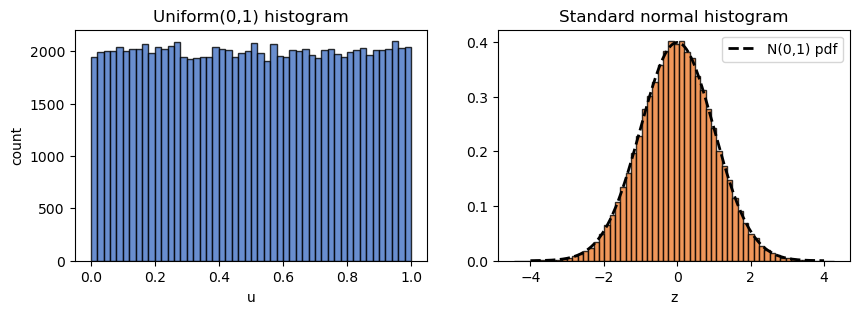

In [4]:
# Uniform[0,1) and standard normal samples
N = 100_000
U = rng.random(N)
Z = rng.standard_normal(N)

fig, axes = plt.subplots(1, 2, figsize=(10,3))
axes[0].hist(U, bins=50, color='#4472c4', alpha=0.8, edgecolor='k')
axes[0].set_title('Uniform(0,1) histogram')
axes[0].set_xlabel('u')
axes[0].set_ylabel('count')

axes[1].hist(Z, bins=60, color='#ed7d31', alpha=0.8, edgecolor='k', density=True)
x = np.linspace(-4,4,400)
axes[1].plot(x, 1/np.sqrt(2*np.pi)*np.exp(-x**2/2), 'k--', lw=2, label='N(0,1) pdf')
axes[1].set_title('Standard normal histogram')
axes[1].set_xlabel('z')
axes[1].legend()
plt.show()


## Estimating $\pi$ by Area (Hit-or-Miss)

Throw random points $(x,y)$ uniformly in the unit square $[0,1]\times[0,1]$. The fraction that land inside the quarter circle $x^2 + y^2 \le 1$ estimates $\pi/4$.

Estimator: $\hat{\pi} = 4\, \frac{1}{N}\sum_{i=1}^N \mathbf{1}\{X_i^2 + Y_i^2 \le 1\}$.


pi_hat = 3.140000 ± 0.014404 (95% CI)


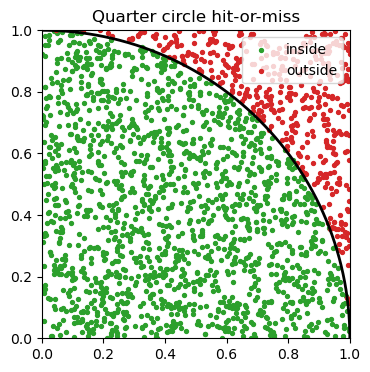

In [5]:
N = 50_000
xy = rng.random((N,2))
r2 = np.sum(xy**2, axis=1)
inside = r2 <= 1.0
pi_hat = 4*inside.mean()
se = 4*np.sqrt(inside.mean()*(1-inside.mean())/N)
print(f"pi_hat = {pi_hat:.6f} ± {1.96*se:.6f} (95% CI)")

# Visualize a subset
M = 2000
xy2 = rng.random((M,2))
r22 = np.sum(xy2**2, axis=1)
fig, ax = plt.subplots(figsize=(4,4))
ax.scatter(xy2[r22<=1,0], xy2[r22<=1,1], s=8, c='#2ca02c', label='inside')
ax.scatter(xy2[r22>1,0],  xy2[r22>1,1],  s=8, c='#d62728', label='outside')
th = np.linspace(0, np.pi/2, 300)
ax.plot(np.cos(th), np.sin(th), 'k-', lw=2)
ax.set_aspect('equal', 'box')
ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_title('Quarter circle hit-or-miss')
ax.legend()
plt.show()


## Buffon's Needle: Geometric Probability for $\pi$

Drop a needle of length $L$ onto a plane with parallel lines spaced by distance $d \ge L$. The probability of crossing a line is $P = \frac{2L}{\pi d}$. For $L=d$, $P=2/\pi$ so $\pi \approx 2/\hat{P}$.


In [6]:
N = 50_000
L = 1.0; d = 1.0
# Center distance to nearest line ~ Uniform(0, d/2)
t = (d/2)*rng.random(N)
# Orientation theta ~ Uniform(0, pi/2)
theta = (np.pi/2)*rng.random(N)
cross = t <= (L/2)*np.sin(theta)
P_hat = cross.mean()
pi_hat = 2/P_hat
se = np.sqrt(P_hat*(1-P_hat)/N)
print(f"Buffon estimate: pi ≈ {pi_hat:.6f} (P̂ = {P_hat:.4f} ± {1.96*se:.4f})")

Buffon estimate: pi ≈ 3.128128 (P̂ = 0.6394 ± 0.0042)



## Integration as an Average Value (Mean of a Function)

A key identity connecting **integration** and **expectation (mean)** is that the average value of a function over an interval is proportional to its integral. Think of the area of the curve as being a solid, which melts into a liquid trapped bewtween $a$ and $b$. For a function $f$ on $[a,b]$,

$\displaystyle \frac{1}{b-a} \int_a^b f(x)\,dx = \mathbb{E}[f(U)]$ where $U \sim \mathrm{Uniform}(a,b)$.

Equivalently,

$\displaystyle \int_a^b f(x)\,dx = (b-a)\, \mathbb{E}[f(U)], \quad U\sim\mathrm{Uniform}(a,b)$.

This is the basis for **Monte Carlo (MC) integration**: sample $U_1,\dots,U_N \sim \mathrm{Uniform}(a,b)$ and estimate

$\displaystyle \hat{I}_N = (b-a)\, \frac{1}{N} \sum_{i=1}^N f(U_i)$.

**Why this works (in brief):**
- If $U\sim \mathrm{Uniform}(a,b)$, its density is $p_U(x) = 1/(b-a)$ on $[a,b]$.
- Then $\mathbb{E}[f(U)] = \int_a^b f(x)\,p_U(x)\,dx = \frac{1}{b-a}\int_a^b f(x)\,dx$.
- By the **Law of Large Numbers**, the sample mean converges to the true mean, so $\hat{I}_N \to I$ as $N\to\infty$.
- **Error scaling**: the standard error of the MC estimate typically scales like $1/\sqrt{N}$.



## Monte Carlo Integration on $[0,1]$

To approximate $I = \int_0^1 f(x)\,dx$, sample $U_i \sim \mathrm{Uniform}(0,1)$ and use
$\hat{I} = \frac{1}{N}\sum_{i=1}^N f(U_i)$.

Example: $f(x)=x^2$ with exact $I=1/3$.


In [7]:

N = 100_000
U = rng.random(N)
f = U**2
I_hat = f.mean()
s = f.std(ddof=1)
se = s/np.sqrt(N)
print(f"Integral of x^2 on [0,1]: {I_hat:.6f} ± {1.96*se:.6f} (true = {1/3:.6f})")


Integral of x^2 on [0,1]: 0.331888 ± 0.001850 (true = 0.333333)


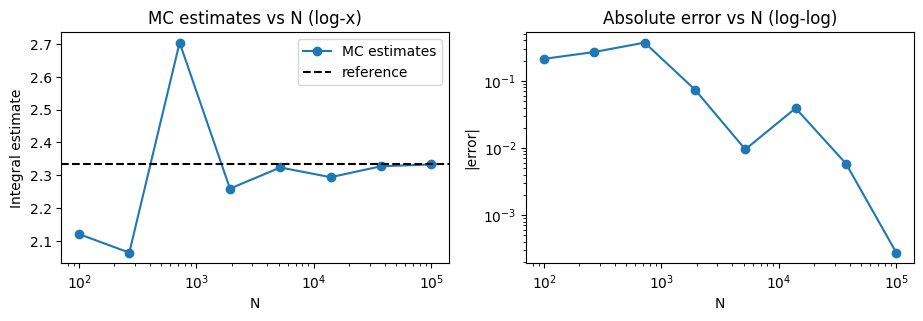

Reference integral (trapz) ≈ 2.333333


In [31]:

import numpy as np
import matplotlib.pyplot as plt

# Function and exact integral on [a,b]
a, b = -2.0, 3.0
f = lambda x: np.cos(2*np.pi*x) + 0.2*x**2

# reference value via fine trapezoid
x_ref = np.linspace(a,b,200_000)
I_ref = np.trapezoid(f(x_ref), x_ref)

Ns = np.logspace(2, 5, 8, dtype=int)
estimates = []
errors = []

rng = np.random.default_rng(2026)
for N in Ns:
    U = rng.random(N)
    X = a + (b-a)*U
    I_hat = (b-a)*np.mean(f(X))
    estimates.append(I_hat)
    errors.append(abs(I_hat - I_ref))

fig, axes = plt.subplots(1,2, figsize=(11,3))
axes[0].plot(Ns, estimates, 'o-', label='MC estimates')
axes[0].axhline(I_ref, color='k', ls='--', label='reference')
axes[0].set_xscale('log')
axes[0].set_title('MC estimates vs N (log-x)')
axes[0].set_xlabel('N'); axes[0].set_ylabel('Integral estimate')
axes[0].legend()

axes[1].plot(Ns, errors, 'o-')
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_title('Absolute error vs N (log-log)')
axes[1].set_xlabel('N'); axes[1].set_ylabel('|error|')
plt.show()

print(f"Reference integral (trapz) ≈ {I_ref:.6f}")



## Random Walks

Basic idea:

- A particle moves to the left or right with equal probability.
- If $N$ particles start at $x=0$ at $t=0$, how does the distribution of particles change over time?
- The random walk can be a model for:
  - Molecular diffusion.
  - Heat transport.
  - Population genetics.
  - Pricing of financial instruments.

Procedure:

- Let $x_n$ be the position of a particle at time $n$.
- We update with the rule $x_{n+1} = x_n + s$, with $s = +1$ or $-1$ with equal probability.
- For $N$ particles, need $N$ equations (or just repeat 1 particle $N$ times).
- Would like to calculate: how does particle distribution change over time?

More formally, consider a 1D symmetric random walk $S_n = \sum_{i=1}^n X_i$ with $X_i\in\{-1,+1\}$ equally likely. Then $\mathbb{E}[S_n]=0$ and $\mathrm{Var}(S_n)=n$.


### 2-D Random walk

In 2-D, we can extend the procedure to:
- $x_{n+1} = x_n + r_x$
- $y_{n+1} = y_n + r_y$
- $r_x = r \cos\theta$
- $r_y = r \sin\theta$
- $r$ fixed (e.g. $r=1$)
- $\theta$ random.


### How far does the random walk go (1-D or 2-D)?

- Start at $(x, y) = (0, 0)$
- $\langle R \rangle = 0$ but $\langle R^2 \rangle \neq 0$
- $\langle R^2 \rangle = (\Delta x)^2 + (\Delta y)^2$
- $\langle R^2 \rangle = (\Delta x_1 + \Delta x_2 + \ldots)^2 + (\Delta y_1 + \Delta y_2 + \ldots)^2$
- Cross terms average to zero, leaving
- $\langle R^2 \rangle = (\Delta x_1^2 + \Delta y_1^2) + (\Delta x_2^2 + \Delta y_2^2) + \ldots$
- $\langle R^2 \rangle = N \langle r^2 \rangle = N r^2$
- $\sqrt{\langle R^2 \rangle} = \sqrt{N} r$


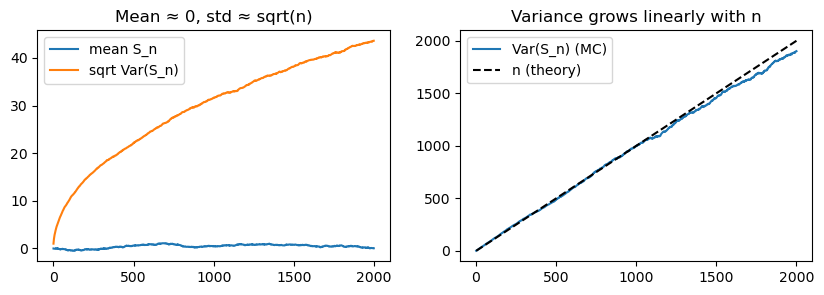

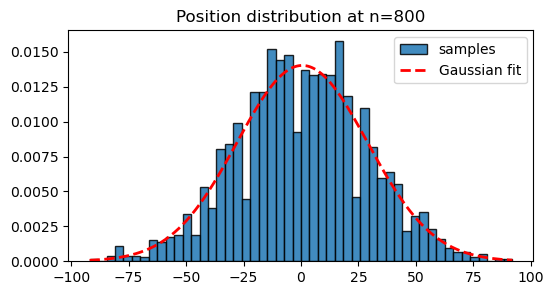

In [8]:

T = 2000
N = 2000

steps = rng.choice([-1,1], size=(N,T))
walks = steps.cumsum(axis=1)
means = walks.mean(axis=0)
vars_ = walks.var(axis=0)

fig, axes = plt.subplots(1,2, figsize=(10,3))
axes[0].plot(means, label='mean S_n')
axes[0].plot(np.sqrt(vars_), label='sqrt Var(S_n)')
axes[0].set_title('Mean ≈ 0, std ≈ sqrt(n)')
axes[0].legend()

n = np.arange(1,T+1)
axes[1].plot(n, vars_, label='Var(S_n) (MC)')
axes[1].plot(n, n, 'k--', label='n (theory)')
axes[1].set_title('Variance grows linearly with n')
axes[1].legend()
plt.show()

# Check Gaussianity at a fixed time via histogram overlay
t_pick = 800
x_t = walks[:, t_pick-1]
mu, sig2 = x_t.mean(), x_t.var()
xs = np.linspace(x_t.min(), x_t.max(), 400)
from math import sqrt, pi
pdf = (1/np.sqrt(2*np.pi*sig2))*np.exp(-(xs-mu)**2/(2*sig2))

plt.figure(figsize=(6,3))
plt.hist(x_t, bins=50, density=True, alpha=0.85, edgecolor='k', label='samples')
plt.plot(xs, pdf, 'r--', lw=2, label='Gaussian fit')
plt.title(f'Position distribution at n={t_pick}')
plt.legend(); plt.show()

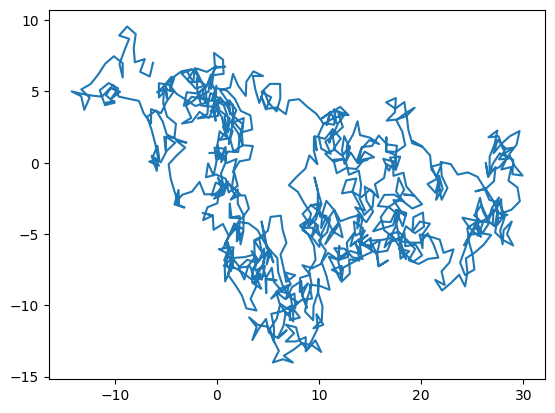

In [26]:
T = 1000
r = 1.0

steps_theta = rng.uniform(-np.pi, np.pi, size=T)
steps_x = r*np.cos(steps_theta)
steps_y = r*np.sin(steps_theta)

walks_x = steps_x.cumsum()
walks_y = steps_y.cumsum()

plt.plot(walks_x, walks_y)

### Continuous limit of random walks

Discrete random walks approximate **diffusion** in the continuum limit. For a symmetric 1D walk $S_n = \sum_{k=1}^n X_k$ with $\mathbb{P}(X_k=\pm 1)=1/2$:

- $\mathbb{E}[S_n]=0$ and $\mathrm{Var}(S_n)=n$ (step variance adds).
- The distribution of $S_n$ approaches a Gaussian as $n$ grows (by the CLT).
- Rescaling time $t=n\,\Delta t$ and space $x = S_n\,\Delta x$ with $(\Delta x)^2/(2\,\Delta t)\to D$ yields the **diffusion equation** for the probability density $p(x,t)$:
  
  $\displaystyle \frac{\partial p}{\partial t} = D\, \frac{\partial^2 p}{\partial x^2}$.

In the diffusion limit, $\langle x^2 \rangle = 2 D t$ with diffusion constant $D$.



## Radioactive Decay as a Poisson Process

If decays follow a Poisson process with rate $\lambda$, inter-arrival times are exponential with density $p(t) = \lambda e^{-\lambda t}$. The number of decays in time $T$ is Poisson with mean $\lambda T$.


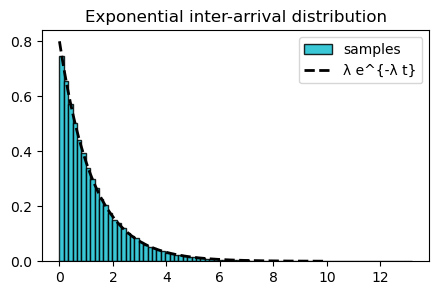

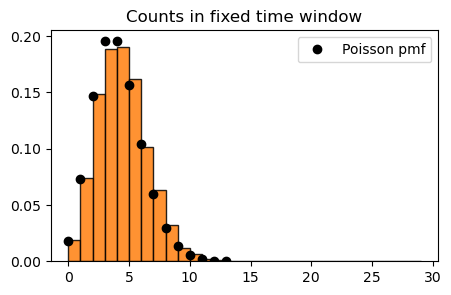

In [9]:

lam = 0.8
N = 100_000
# Inter-arrival times
t = rng.exponential(scale=1/lam, size=N)

fig, ax = plt.subplots(figsize=(5,3))
ax.hist(t, bins=80, density=True, alpha=0.85, edgecolor='k', color='#17becf', label='samples')
x = np.linspace(0, 8/lam, 400)
ax.plot(x, lam*np.exp(-lam*x), 'k--', lw=2, label='λ e^{-λ t}')
ax.set_title('Exponential inter-arrival distribution')
ax.legend(); plt.show()

# Counts in fixed window T
T = 5.0
trials = 10_000
counts = rng.poisson(lam*T, size=trials)

fig, ax = plt.subplots(figsize=(5,3))
ax.hist(counts, bins=range(0, int(5*lam*T)+10), density=True, alpha=0.85, edgecolor='k', color='#ff7f0e')
# Overlay Poisson pmf via bars
k = np.arange(0, counts.max()+1)
from math import factorial
pmf = np.exp(-lam*T)*(lam*T)**k/np.array([factorial(int(i)) for i in k])
ax.plot(k, pmf, 'ko', label='Poisson pmf')
ax.set_title('Counts in fixed time window')
ax.legend(); plt.show()



### Radioactive Decay and Poisson Processes

Radioactive decays are often modeled as a **homogeneous Poisson process** with rate $\lambda$ per unit time.

**Core properties:**
- **Inter-arrival times** are i.i.d. exponential: $p(t) = \lambda e^{-\lambda t}$.
- **Counts in a window** $[0,T]$ are Poisson: $N(T) \sim \mathrm{Poisson}(\lambda T)$.
- **Survival law for a single nucleus:** $S(t)=\mathbb{P}(\text{no decay by }t)=e^{-\lambda t}$; mean lifetime $1/\lambda$; half-life $t_{1/2} = (\ln 2)/\lambda$.
- **Population decay:** for $N_0$ independent nuclei, $\mathbb{E}[N(t)] = N_0 e^{-\lambda t}$.
- **Superposition & thinning:** sums of independent Poisson processes are Poisson; to simulate a time-varying rate $\lambda(t)$, use **thinning**.

Below are complementary simulation approaches.


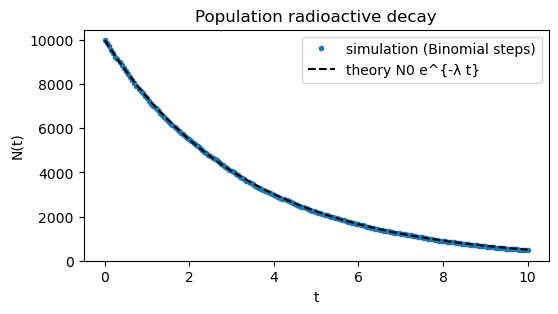

In [10]:

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(2025)
N0 = 10_000
lam = 0.3
Tmax = 10.0
dt = 0.05
steps = int(Tmax/dt)

N = np.empty(steps+1, dtype=int)
N[0] = N0
for k in range(1, steps+1):
    # Each nucleus survives with prob exp(-lam*dt) over dt
    # Number of survivors ~ Binomial(N[k-1], exp(-lam*dt))
    survive_prob = np.exp(-lam*dt)
    N[k] = rng.binomial(N[k-1], survive_prob)

t = np.linspace(0, Tmax, steps+1)
N_theory = N0*np.exp(-lam*t)

plt.figure(figsize=(6,3))
plt.plot(t, N, 'o', ms=3, label='simulation (Binomial steps)')
plt.plot(t, N_theory, 'k--', label='theory N0 e^{-λ t}')
plt.xlabel('t'); plt.ylabel('N(t)'); plt.title('Population radioactive decay')
plt.legend(); plt.show()


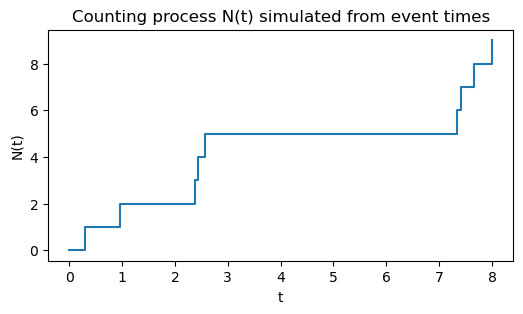

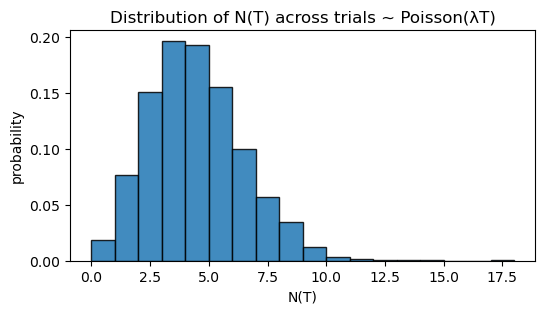

In [11]:

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(11)
lam = 0.8
Tmax = 8.0

# Draw inter-arrival times ~ Exp(lam) until sum exceeds Tmax
inter = []
S = 0.0
while True:
    S += rng.exponential(scale=1/lam)
    if S > Tmax:
        break
    inter.append(S)

# Construct counting process N(t)
Ts = np.array(inter)

# Build a time grid and counts
grid = np.linspace(0, Tmax, 300)
counts = np.array([np.sum(Ts <= g) for g in grid])

plt.figure(figsize=(6,3))
plt.step(grid, counts, where='post')
plt.title('Counting process N(t) simulated from event times')
plt.xlabel('t'); plt.ylabel('N(t)'); plt.show()

# Distribution of N(T) across many trials matches Poisson(lam*T)
T = 5.0
trials = 5000
NT = np.empty(trials, dtype=int)
for i in range(trials):
    NT[i] = rng.poisson(lam*T)

plt.figure(figsize=(6,3))
plt.hist(NT, bins=range(NT.min(), NT.max()+2), density=True, alpha=0.85, edgecolor='k')
plt.title('Distribution of N(T) across trials ~ Poisson(λT)')
plt.xlabel('N(T)'); plt.ylabel('probability'); plt.show()



## Uncertainty Propagation by Monte Carlo

Suppose $a$ and $b$ are measured with uncertainties $a \sim \mathcal{N}(\mu_a,\sigma_a^2)$ and $b \sim \mathcal{N}(\mu_b,\sigma_b^2)$. For a derived quantity $f(a,b)$, propagate uncertainty by sampling and evaluating $f$.

Example: $f(a,b)=a/b$.


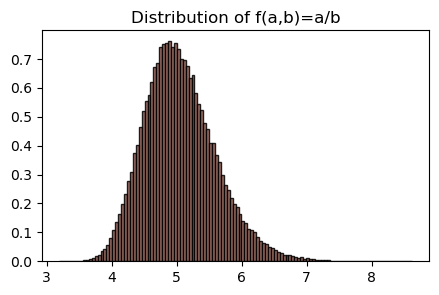

E[f] ≈ 5.0542 ± 0.0035 (95% CI)


In [12]:

N = 100000
mu_a, sigma_a = 10.0, 0.4
mu_b, sigma_b = 2.0, 0.2
A = rng.normal(mu_a, sigma_a, size=N)
B = rng.normal(mu_b, sigma_b, size=N)
F = A/B

mean = F.mean(); se = F.std(ddof=1)/np.sqrt(N)
ci = (mean-1.96*se, mean+1.96*se)

fig, ax = plt.subplots(figsize=(5,3))
ax.hist(F, bins=120, density=True, color='#8c564b', alpha=0.85, edgecolor='k')
ax.set_title('Distribution of f(a,b)=a/b')
plt.show()

print(f"E[f] ≈ {mean:.4f} ± {1.96*se:.4f} (95% CI)")


## The Metropolis Algorithm

**Goal:** Draw samples from a target density $\pi(x)$ known up to a constant (e.g., Boltzmann distributions in physics). Metropolis constructs a Markov chain with $\pi$ as its stationary distribution.

**Algorithm (random-walk Metropolis):**
- Propose $x' = x + \epsilon$, where $\epsilon \sim q(\cdot)$ is symmetric (e.g., $\mathcal{N}(0,\sigma^2)$).
- Compute acceptance probability $\alpha(x\to x') = \min\{1, \pi(x')/\pi(x)\}$.
- Accept with probability $\alpha$ (set $x\leftarrow x'$), otherwise stay at $x$.

**Key ideas:**
- **Detailed balance:** $\pi(x)K(x\to x') = \pi(x')K(x'\to x)$ ensures $\pi$ is stationary.
- **Tuning $\sigma$ (proposal scale):** too small $\Rightarrow$ high acceptance but slow exploration; too large $\Rightarrow$ low acceptance and sticky chain. For 1D normals, acceptance rates $\approx 0.3$–$0.6$ are often reasonable.
- **Burn-in:** discard early iterations before the chain is well-mixed.
- **Autocorrelation / Effective Sample Size (ESS):** quantify dependence between successive draws; higher ESS is better.

### Tiny 2D Ising Model (Metropolis)

Hamiltonian $H(\sigma) = -J \sum_{\langle i,j\rangle} \sigma_i \sigma_j$ with $\sigma_i \in \{-1,+1\}$. Use periodic boundary conditions and Metropolis updates at inverse temperature $\beta = 1/(k_B T)$ (set $k_B=J=1$).

Acceptance probability for flipping spin $\sigma_i \to -\sigma_i$:
$\alpha = \min\{1, \exp(-\beta\,\Delta H)\}$ where $\Delta H$ is the energy change.


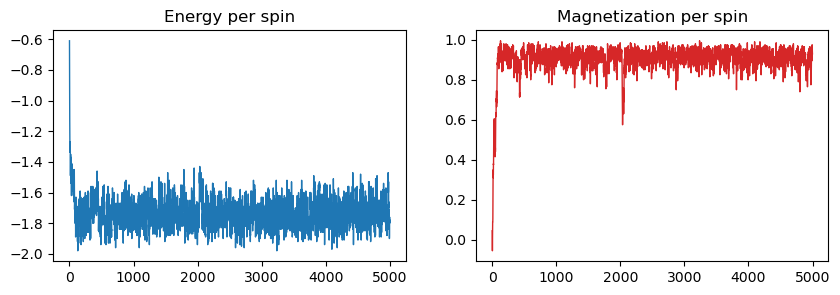

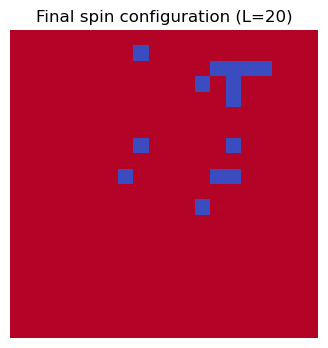

In [13]:

L = 20
beta = 0.5   # relatively high temperature (disordered)
steps = 5_000
rng = np.random.default_rng(7)

# Initialize spins randomly in {-1,+1}
spins = rng.choice([-1,1], size=(L,L))

# Neighbor sum with periodic boundaries
def neighbor_sum(i,j, arr):
    return (arr[(i+1)%L, j] + arr[(i-1)%L, j] + arr[i, (j+1)%L] + arr[i, (j-1)%L])

E_list = []
M_list = []

for s in range(steps):
    for _ in range(L*L):
        i = rng.integers(0, L)
        j = rng.integers(0, L)
        s_ij = spins[i,j]
        nb = neighbor_sum(i,j, spins)
        dE = 2*s_ij*nb  # with J=1
        if np.log(rng.random()) < -beta*dE:
            spins[i,j] = -s_ij
    # track energy and magnetization per spin
    E = 0
    for i in range(L):
        for j in range(L):
            E += -spins[i,j]*(spins[(i+1)%L,j] + spins[i,(j+1)%L])
    E_list.append(E/(L*L))
    M_list.append(spins.mean())

fig, axes = plt.subplots(1,2, figsize=(10,3))
axes[0].plot(E_list, lw=1)
axes[0].set_title('Energy per spin')
axes[1].plot(M_list, lw=1, color='#d62728')
axes[1].set_title('Magnetization per spin')
plt.show()

plt.figure(figsize=(4,4))
plt.imshow(spins, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Final spin configuration (L=20)')
plt.axis('off')
plt.show()
